In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/GPT-from-Scratch/notebooks/"
os.chdir(PROJECT_DIR)
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/GPT-from-Scratch/notebooks


In [2]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from functools import partial

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
tokenizer = Tokenizer.from_file("../src/tokenizer/arabic_bpe_tokenizer.json")

with open("../data/finetune/sft_data.json", "r", encoding="utf-8") as f:
    sft_data = json.load(f)

print("Total SFT samples:", len(sft_data))

Total SFT samples: 200


In [5]:
def format_input(entry):
    instruction_text = (
        "فيما يلي تعليمات تصف مهمة. "
        "اكتب استجابة مناسبة تكمل الطلب."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""

    return instruction_text + input_text

In [6]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            encoded = tokenizer.encode(full_text).ids
            self.encoded_texts.append(encoded)

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [7]:
train_portion = int(len(sft_data) * 0.85)
test_portion = int(len(sft_data) * 0.10)
val_portion = len(sft_data) - train_portion - test_portion

train_data = sft_data[:train_portion]
test_data = sft_data[train_portion:train_portion + test_portion]
val_data = sft_data[train_portion + test_portion:]

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 170
Val: 10
Test: 20


In [8]:
def custom_collate_fn(
    batch,
    pad_token_id=0,
    ignore_index=-100,
    allowed_max_length=128,
    device="cpu"
):
    batch_max_length = min(max(len(item) + 1 for item in batch), allowed_max_length + 1)

    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        padded = padded[:batch_max_length]

        inputs = torch.tensor(padded[:-1], dtype=torch.long)
        targets = torch.tensor(padded[1:], dtype=torch.long)

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [9]:
vocab = tokenizer.get_vocab()
PAD_ID = vocab["[PAD]"]

customized_collate_fn = partial(
    custom_collate_fn,
    pad_token_id=PAD_ID,
    allowed_max_length=128,
    device=device
)

train_dataset = InstructionDataset(train_data, tokenizer)
val_dataset = InstructionDataset(val_data, tokenizer)
test_dataset = InstructionDataset(test_data, tokenizer)

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 21
Val batches: 2
Test batches: 3


In [10]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [11]:
class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi, device=x.device)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [12]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2).contiguous()
        context_vec = context_vec.view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_resid(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut

        return x

In [15]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [16]:
GPT_CONFIG = {
    "vocab_size": 5000,
    "context_length": 128,
    "emb_dim": 256,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [17]:
model = GPTModel(GPT_CONFIG).to(device)
model.load_state_dict(torch.load("../checkpoints/pretrained/pretrained_model.pth", map_location=device))
print("Pretrained model loaded.")

Pretrained model loaded.


In [18]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

def decode_ids(ids, tokenizer):
    return tokenizer.decode(ids.squeeze(0).tolist())

In [19]:
test_prompt = format_input(test_data[0])
print("Prompt:\n", test_prompt)

prompt_ids = tokenizer.encode(test_prompt).ids
input_tensor = torch.tensor(prompt_ids, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
generated = generate_text_simple(
    model=model,
    idx=input_tensor,
    max_new_tokens=40,
    context_size=GPT_CONFIG["context_length"]
)

before_text = decode_ids(generated.cpu(), tokenizer)
print("\nBefore fine-tuning:\n")
print(before_text)

Prompt:
 فيما يلي تعليمات تصف مهمة. اكتب استجابة مناسبة تكمل الطلب.

### Instruction:
اكتب فقرة قصيرة من ثلاث جمل عن القمر.

Before fine-tuning:

فيما يلي ت علي مات تصف م همة . ا كتب است ج ابة مناسبة تك مل الط لب . In s t r u c tion : ا كتب فق رة قصيرة من ثلاث جمل عن الق مر . - ( ٢ ) … ( ١ ) … ( ٢ ) … ( ٢ ) … ( ١ ) … ( راجع الجزء الخامس ). - ( راجع : L . D . S : L . D .


In [20]:
def calc_loss_batch(input_batch, target_batch, model):
    logits = model(input_batch)
    loss = F.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten(),
        ignore_index=-100
    )
    return loss

In [21]:
def calc_loss_loader(data_loader, model, num_batches=None):
    total_loss = 0.0

    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    model.eval()
    with torch.no_grad():
        for i, (input_batch, target_batch) in enumerate(data_loader):
            if i >= num_batches:
                break
            loss = calc_loss_batch(input_batch, target_batch, model)
            total_loss += loss.item()

    return total_loss / num_batches

In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 3
eval_freq = 10

train_losses = []
val_losses = []
steps = []

In [23]:
global_step = 0

for epoch in range(num_epochs):
    model.train()

    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()

        loss = calc_loss_batch(input_batch, target_batch, model)
        loss.backward()
        optimizer.step()

        if global_step % eval_freq == 0:
            train_loss = calc_loss_loader(train_loader, model, num_batches=10)
            val_loss = calc_loss_loader(val_loader, model, num_batches=2)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            steps.append(global_step)

            print(f"Epoch {epoch+1}, Step {global_step}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

        global_step += 1

Epoch 1, Step 0: train_loss=7.4559, val_loss=7.2879
Epoch 1, Step 10: train_loss=5.8184, val_loss=6.0726
Epoch 1, Step 20: train_loss=4.5778, val_loss=5.1255
Epoch 2, Step 30: train_loss=3.7685, val_loss=4.5468
Epoch 2, Step 40: train_loss=3.1340, val_loss=3.9930
Epoch 3, Step 50: train_loss=2.6281, val_loss=3.6791
Epoch 3, Step 60: train_loss=2.2867, val_loss=3.4024


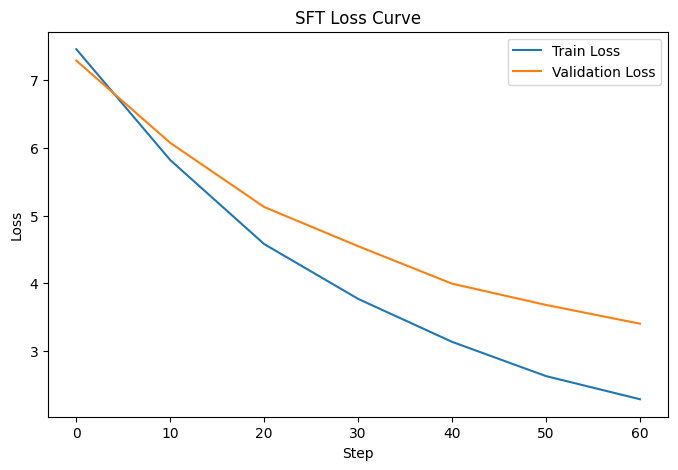

In [24]:
plt.figure(figsize=(8,5))
plt.plot(steps, train_losses, label="Train Loss")
plt.plot(steps, val_losses, label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("SFT Loss Curve")
plt.legend()
plt.savefig("../results/plots/sft_loss.png")
plt.show()

In [25]:
prompt_ids = tokenizer.encode(test_prompt).ids
input_tensor = torch.tensor(prompt_ids, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
generated = generate_text_simple(
    model=model,
    idx=input_tensor,
    max_new_tokens=40,
    context_size=GPT_CONFIG["context_length"]
)

after_text = decode_ids(generated.cpu(), tokenizer)

print("Prompt:\n")
print(test_prompt)

print("\nAfter fine-tuning:\n")
print(after_text)

Prompt:

فيما يلي تعليمات تصف مهمة. اكتب استجابة مناسبة تكمل الطلب.

### Instruction:
اكتب فقرة قصيرة من ثلاث جمل عن القمر.

After fine-tuning:

فيما يلي ت علي مات تصف م همة . ا كتب است ج ابة مناسبة تك مل الط لب . In s t r u c tion : ا كتب فق رة قصيرة من ثلاث جمل عن الق مر .


In [26]:
torch.save(model.state_dict(), "../checkpoints/finetuned/sft_model.pth")
print("Fine-tuned model saved.")

Fine-tuned model saved.
